<a href="https://colab.research.google.com/github/dheep2305-git/Tsf-tasks/blob/main/tsf_task_10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

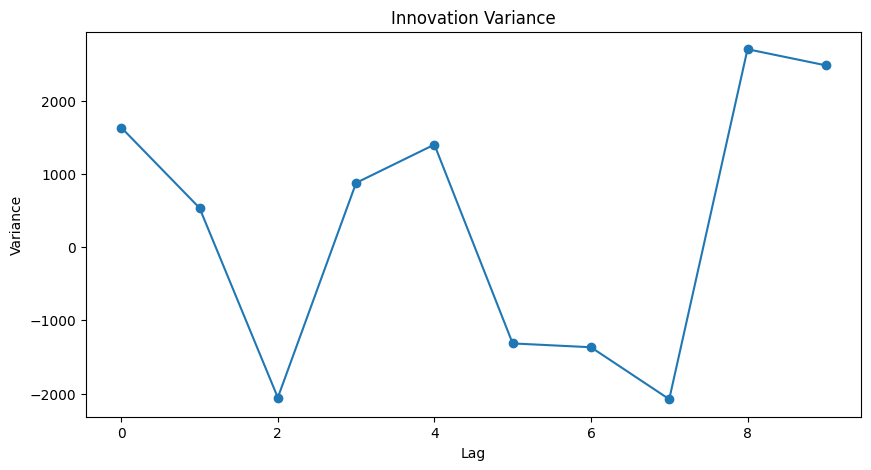

Innovation Coefficients (theta):
[[ 0.          0.          0.          0.          0.          0.
   0.          0.          0.          0.        ]
 [ 0.82020129  0.          0.          0.          0.          0.
   0.          0.          0.          0.        ]
 [ 0.45126849  2.50619276  0.          0.          0.          0.
   0.          0.          0.          0.        ]
 [ 0.03957655  1.37888813 -0.35741826  0.          0.          0.
   0.          0.          0.          0.        ]
 [-0.27579196  0.12092942 -0.33259147 -0.61190809  0.          0.
   0.          0.          0.          0.        ]
 [-0.42523943 -0.8427051  -0.21106737  0.88732852  1.093869    0.
   0.          0.          0.          0.        ]
 [-0.37659509 -1.29935418 -0.05796416  1.71802345  1.00603335 -1.27264701
   0.          0.          0.          0.        ]
 [-0.15737391 -1.15071738  0.09240253  1.78733564  0.63248502 -0.41114158
   0.34046466  0.          0.          0.        ]
 [ 0.15820254 -

In [ ]:
# TASK 10
# Innovations Algorithm

# Step 1: Import libraries
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.datasets import sunspots


# Step 2: Load inbuilt dataset
data = sunspots.load_pandas().data

ts = data['SUNACTIVITY'].values


# Step 3: Preprocess (mean centering)
ts = ts - np.mean(ts)

N = len(ts)


# Step 4: Compute autocovariance
def autocovariance(x, lag):

    n = len(x)

    mean = np.mean(x)

    return np.sum(
        (x[:n-lag] - mean) *
        (x[lag:] - mean)
    ) / n


max_lag = 10

gamma = np.array([
    autocovariance(ts, k)
    for k in range(max_lag)
])


# Step 5: Initialize
theta = np.zeros((max_lag, max_lag))

v = np.zeros(max_lag)


# Step 6: Initial variance
v[0] = gamma[0]


# Step 7-10: Innovations Algorithm
for n in range(1, max_lag):

    for k in range(n):

        if k == 0:

            sum_val = 0

        else:

            sum_val = sum(
                theta[k-1, j] * gamma[n-j-1]
                for j in range(k)
            )

        theta[n, k] = (
            gamma[n-k] - sum_val
        ) / v[k]

    # Step 8: Update variance
    v[n] = gamma[0] - sum(
        theta[n, j]**2 * v[j]
        for j in range(n)
    )


# Step 9: Innovations (prediction errors)
innovations = np.zeros(N)

for t in range(1, N):

    pred = sum(
        theta[min(t-1, max_lag-1), j] *
        ts[t-j-1]
        for j in range(min(t, max_lag))
    )

    innovations[t] = ts[t] - pred


# Step 11: Plot innovation variance
plt.figure(figsize=(10, 5))

plt.plot(
    v,
    marker='o'
)

plt.title("Innovation Variance")
plt.xlabel("Lag")
plt.ylabel("Variance")

plt.show()


# Step 12: Display results
print("Innovation Coefficients (theta):")
print(theta)

print("\nPrediction Error Variance:")
print(v)